### Dataset

In [1]:
import pandas as pd
df = pd.read_csv("merged.csv")
print(df.shape)
df.head()

(696, 12)


,Monthly_Increase,Month,Year,Volatility,cpi_pct,fedfunds_rate,unemployment_rate,CIVPART,Monthly_Increase_next_month,cpi_pct_lag1,fedfunds_rate_lag1,unemployment_rate_lag1
0,-3.870003,1,1968,0.068666,3.651861,4.75,3.7,59.2,-3.199997,NaN,NaN,NaN
1,-3.199997,2,1968,0.107240,3.673819,4.75,3.8,59.6,1.089996,3.651861,4.75,3.7
2,1.089996,3,1968,0.132372,4.142164,5.25,3.7,59.6,4.979996,3.673819,4.75,3.8
3,4.979996,4,1968,0.138902,4.155828,6.25,3.5,59.5,0.709999,4.142164,5.25,3.7
4,0.709999,5,1968,0.068541,4.088245,6.13,3.5,59.9,-0.409996,4.155828,6.25,3.5


In [2]:
df.dropna(inplace=True)
df.isna().sum()

Monthly_Increase               0
Month                          0
Year                           0
Volatility                     0
cpi_pct                        0
fedfunds_rate                  0
unemployment_rate              0
CIVPART                        0
Monthly_Increase_next_month    0
cpi_pct_lag1                   0
fedfunds_rate_lag1             0
unemployment_rate_lag1         0
dtype: int64

### Linear Regression 

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Use 1-period lags for explanatory variables
df_lag = df.copy()
lag_features = ["cpi_pct", "fedfunds_rate", "unemployment_rate", ]
for col in lag_features:
    df_lag[f"{col}_lag1"] = df_lag[col].shift(1)

# Drop rows created by lagging
df_lag = df_lag.dropna(subset=[f"{col}_lag1" for col in lag_features] + ["Monthly_Increase"])

# Features and target
X = df_lag[["cpi_pct_lag1", "fedfunds_rate_lag1", "unemployment_rate_lag1"]]
y = df_lag["Monthly_Increase"]

print(len(X), len(y))
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef_df)
print("Intercept:", model.intercept_)

692 692
R2: -0.004851914142200542
MSE: 4680.737172193103
                  Feature  Coefficient
0            cpi_pct_lag1    -0.699526
1      fedfunds_rate_lag1    -0.398997
2  unemployment_rate_lag1    -0.155565
Intercept: 12.533408846966463


### Data Visualization

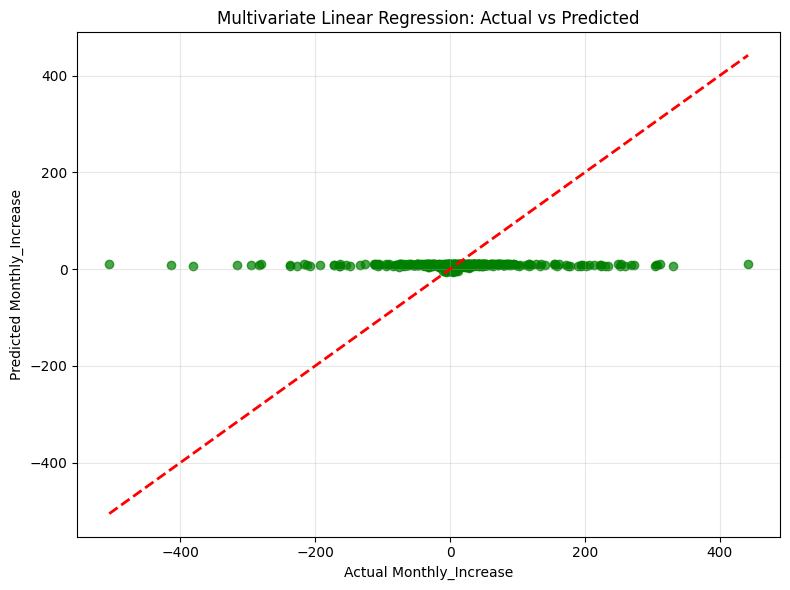

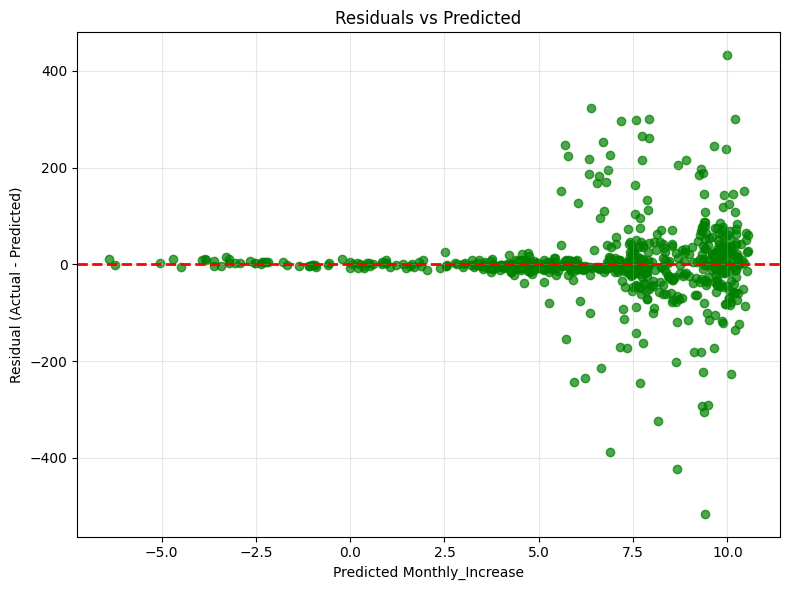

Saved: actual_vs_predicted.png
Saved: residuals_vs_predicted.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Multivariate regression visualization (all 3 X features together)
y_pred_all = model.predict(X)
residuals = y - y_pred_all

# 1) Actual vs Predicted (separate figure)
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_all, alpha=0.7, color='green')
line_min = min(y.min(), y_pred_all.min())
line_max = max(y.max(), y_pred_all.max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--', lw=2)
plt.xlabel('Actual Monthly_Increase')
plt.ylabel('Predicted Monthly_Increase')
plt.title('Multivariate Linear Regression: Actual vs Predicted')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# 2) Residuals vs Predicted (separate figure)
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_all, residuals, alpha=0.7, color='green')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Monthly_Increase')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs Predicted')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('residuals_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: actual_vs_predicted.png')
print('Saved: residuals_vs_predicted.png')